In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# This script targets the Python client API version 2.0.0 and later
import labkey
from labkey.api_wrapper import APIWrapper

In [2]:
working_dir="/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/AMP_Fig_S5/"

In [3]:
def fivepl(xx, betas):
    lower, upper, asymm, slope, inflection = betas
    return upper + (lower-upper) / (1 + (xx/inflection)**slope)**asymm

In [4]:
# desired isolates, shared from Li
post = pd.read_csv(
    "/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/data/selectedpubids_postWk80.csv",
)
wk80 = pd.read_csv(
    "/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/data/selectedpubids_wk80.csv",
)

post['cat'] = 'post_wk80'
wk80['cat'] = 'wk80'
df = pd.concat([wk80, post])

# merge on ptids, foudn in analysis dir
pubids703 = pd.read_sas(
    "/trials/vaccine/p703/analysis/adata/enrolled.sas7bdat"
)
pubids704 = pd.read_sas(
    "/trials/vaccine/p704/analysis/adata/enrolled.sas7bdat"
)

pubids703.pub_id = pubids703.pub_id.astype(str)
pubids704.pub_id = pubids704.pub_id.astype(str)
pubids = pd.concat([pubids703, pubids704])
df = df.merge(pubids[['pub_id','ptid']], how='left')

# merge on isolate names from qdata
bids704 = pd.read_csv("/trials/vaccine/p704/s670/qdata/VSEQ/breakthrough/HVTN704_VSEQ_20211004.txt", sep="\t")
bids703 = pd.read_csv("/trials/vaccine/p703/s573/qdata/VSEQ/breakthrough_20221006/HVTN703_VSEQ_20221006.txt", sep="\t")
bids = pd.concat([bids703, bids704])

df = df.merge(bids[['PTID','PLASMID_NAME']], left_on='ptid', right_on='PTID', how='left')

# misc cleanup 
df.phenotype = df.phenotype.map({'sensitive': 'Sensitive', 'resistant': 'Resistant'})

tx_map = {'C3': 'placebo', 'T2': 'high dose', 'T1': 'low dose'}
df['group'] = df.tx.map(tx_map)

color_map = {'placebo':'black', 'high dose':'cornflowerblue', 'low dose':'green'}

week_map = {'wk80': 'Weeks 0-80', 'post_wk80': 'Weeks 80-104'}
df['week_label'] = df.cat.map(week_map)
df = df.sort_values(by=['week_label','phenotype'])

In [5]:
# dilution level data from qdata
dat703 = pd.read_csv(
    "/trials/vaccine/p703/s573/qdata/Dilution_level_nab_data/VTN703_NAB_dilution_level_data_Breakthrough_20200928_E002_A.tsv",
    sep="\t"
)

dat704 = pd.read_csv(
    "/trials/vaccine/p704/s670/qdata/Dilution_level_nab_data/VTN704_NAB_dilution_level_data_Breakthrough_20201003_E001_A.txt",
    sep="\t"
)

dat = pd.concat([dat703, dat704])
dat = dat.rename(columns={'Virus Name - Other':'isolate'})
dat['pct_neutralization'] = dat['Percent Neutralization'].str[:-1].astype(float)

# choose most resistant isolates per pub_id
q704 = pd.read_csv("/trials/vaccine/p704/s670/qdata/VTN704_breakthrough_NAb_20200910.txt", sep="\t")
q703 = pd.read_csv('/trials/vaccine/p703/s573/qdata/VTN703_breakthrough_NAb_20200722.txt', sep="\t")
qdat = pd.concat([q703, q704])

dat = dat.merge(df[['PLASMID_NAME','pub_id']], left_on='isolate', right_on='PLASMID_NAME', how='left')
qdat = qdat.merge(df[['PLASMID_NAME','pub_id']], left_on='isolate', right_on='PLASMID_NAME', how='left')
dat = dat.loc[dat.pub_id.notna()]
qdat = qdat.loc[qdat.pub_id.notna()]

# qdat = qdat.loc[qdat.poscrit==80] # might update this if they want IC50s also
qdat['titer_numeric'] = qdat.titer.str.replace(">","").str.replace("<","").astype(float)
qdat['gmean_titer_initdil'] = qdat.groupby(['poscrit','PLASMID_NAME','initdilution']).titer_numeric.transform(lambda x: np.exp(np.mean(np.log(x))))
qdat['gmean_titer'] = qdat.groupby(['poscrit','PLASMID_NAME']).titer_numeric.transform(lambda x: np.exp(np.mean(np.log(x))))

qdat80 = qdat.loc[qdat.poscrit==80]
isolate_choices = qdat80.loc[qdat80.groupby('pub_id')['gmean_titer'].idxmax(),
             ['pub_id', 'PLASMID_NAME', 'gmean_titer']].reset_index(drop=True)

# merge IC50s/80s on --- tho this was an artifact of an earlier version, ended up using the pre-calculated titers 
# so probably this chunk of code could be deleted
df = df.merge(isolate_choices, on=['pub_id','PLASMID_NAME'], how='left')

gmean_titers50 = qdat.loc[(qdat.poscrit==50)&(qdat.PLASMID_NAME.isin(isolate_choices.PLASMID_NAME)),['pub_id','PLASMID_NAME','gmean_titer']].drop_duplicates()
gmean_titers50 = gmean_titers50.rename(columns={'gmean_titer':'gmean_titer50'})

df = df.rename(columns={'gmean_titer':'gmean_titer80'})
df = df.merge(gmean_titers50, on=['pub_id','PLASMID_NAME'])

In [ ]:
### SAVE QDATA TO NETWORK DRIVE WITH NUMERIC PROP NEUTRALIZATION FOR MONOLIX FITTING
# dat['prop_neutralization'] = dat.pct_neutralization / 100.
# dat.to_csv(
#     '/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/data/dilution_level_data.csv', index=False
# )

In [6]:
titers = pd.read_csv(
    '/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/ic_estimates/HVTN703_704_IC50_80_estimates_2026-05-07.txt',
    sep="\t"
)

In [7]:
monolix_params1 = pd.read_csv(
    '/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/working_dir/HVTN703_704_nAb_pnmle_p1/IndividualParameters/estimatedIndividualParameters.txt',
)

monolix_params1 = monolix_params1[['id','L_mode','U_mode','s_mode','m_mode','e_mode']]
monolix_params1.U_mode = monolix_params1.U_mode * 100
monolix_params1.L_mode = monolix_params1.L_mode * 100

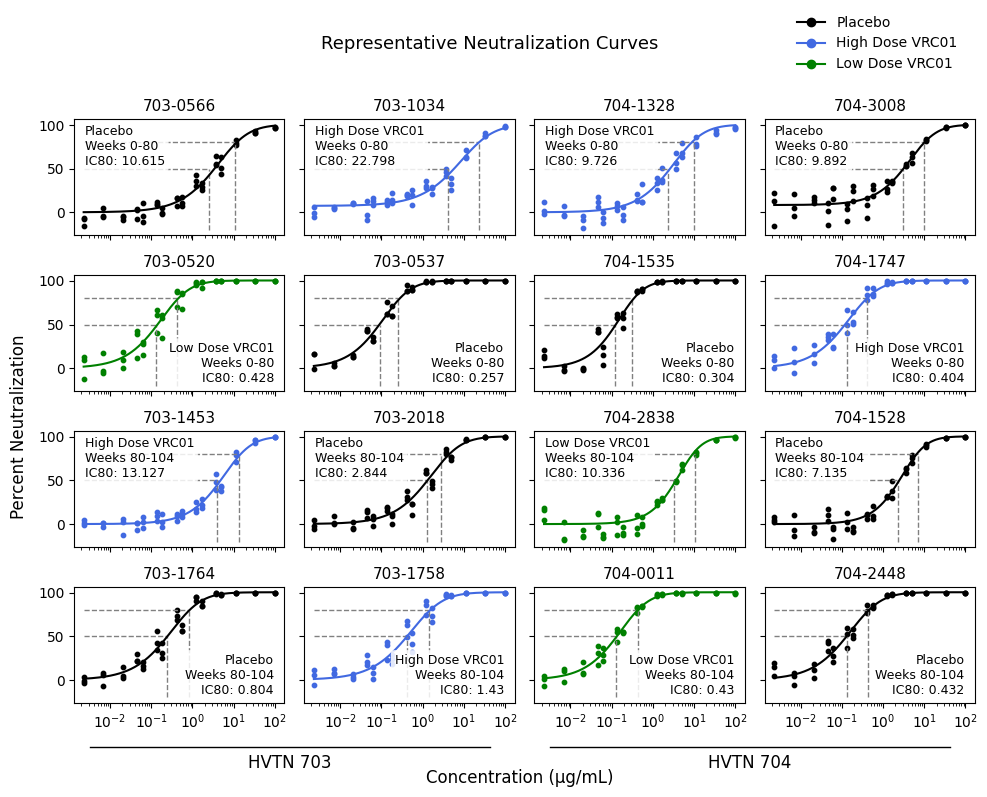

In [8]:
xx = np.exp(np.linspace(
    np.log(dat.Dilution.min()),
    np.log(dat.Dilution.max()),
    1_000
))

fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)

i = 0
param_cols = ['lower','upper','asymm','slope','inflection']
color_map = {'placebo':'black', 'high dose':'royalblue', 'low dose':'green'}
tx_map = {'placebo': 'Placebo', 'high dose': 'High Dose VRC01', 'low dose': 'Low Dose VRC01'}

for i, row in df.reset_index().iterrows():
    ax = axes[i//4, i%4]
    isolate = row.PLASMID_NAME
    pub_id = row.pub_id

    ic50 = titers.loc[(titers.isolate==isolate) & (titers.poscrit==50)].mu.tolist()[0]
    ic80 = titers.loc[(titers.isolate==isolate) & (titers.poscrit==80)].mu.tolist()[0]

    group = row.group
    color = color_map[group]

    ax.plot([xx[0], ic80], [80, 80], ls='--', color='gray', linewidth=1) 
    ax.plot([ic80, ic80], [-20, 80], ls='--', color='gray', linewidth=1) 

    ax.plot([xx[0], ic50], [50, 50], ls='--', color='gray', linewidth=1) 
    ax.plot([ic50, ic50], [-20, 50], ls='--', color='gray', linewidth=1) 

    t = dat.loc[(dat.PLASMID_NAME==row.PLASMID_NAME)]
    if len(t) > 0:
        ax.scatter(
            t.Dilution,
            t.pct_neutralization,
            label=row.PLASMID_NAME,
            s=10,
            color=color
        )
    s = monolix_params1.loc[monolix_params1.id==row.PLASMID_NAME]
    if len(s) > 0:
        betas = s[['L_mode','U_mode','s_mode','m_mode','e_mode']].values[0]
        y = fivepl(xx, betas)
        ax.plot(xx, y, color=color)
    
    pheno = row.phenotype
    week = row.week_label
    trial = row.protocol
    
    ax.set_xscale("log")

    # simpler title
    ax.set_title(f"{pub_id}", fontsize=11)

    if ic80 < 2.:
        text_x = 0.95
        text_y = 0.05
        ha = 'right'
        va = 'bottom'
    else:
        text_x = 0.05
        text_y = 0.95
        ha = 'left'
        va = 'top'
    
    ax.text(
        text_x,
        text_y,
        f"{tx_map[group]}\n{week}\nIC80: {np.round(ic80, 3)}",
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=9,
        color='black',
        clip_on=True,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
            boxstyle='round,pad=0.3'
        )
    )

# create legend handles manually
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='-',
        color=color_map[g],
        label=tx_map[g],
        markersize=6
    )
    for g in color_map.keys()
]

# add one shared legend for whole figure
fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.98, 1.03),
    frameon=False
)

# horizontal divider lines
fig.add_artist(Line2D(
    [0.1, 0.5],   # x start/end in figure coords
    [0.1, 0.1], # y position
    transform=fig.transFigure,
    color='black',
    linewidth=1
))

fig.add_artist(Line2D(
    [0.56, 0.96],
    [0.1, 0.1],
    transform=fig.transFigure,
    color='black',
    linewidth=1
))

fig.text(
    0.3, 0.08,
    "HVTN 703",
    ha='center',
    va='center',
    fontsize=12
)

fig.text(
    0.76, 0.08,
    "HVTN 704",
    ha='center',
    va='center',
    fontsize=12
)

fig.supxlabel("Concentration (μg/mL)", y=0.05, x=0.53)
fig.supylabel("Percent Neutralization")

plt.suptitle(
    "Representative Neutralization Curves",
    y=0.99,
    fontsize=13
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
# plt.savefig(working_dir+"AMP_nAb_representative_curves_2026-05-28.pdf", bbox_inches='tight')
# plt.savefig(working_dir+"AMP_nAb_representative_curves_2026-05-28.svg", bbox_inches='tight')
plt.show()